<a href="https://colab.research.google.com/github/annatsamoyra-prog/anna/blob/main/number_of_upvotes_a_post_will_get.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import sklearn
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import seaborn as sns

In [23]:
df = pd.read_csv("/content/train_NIR5Yl1.csv (1).zip")

In [24]:
print(df.head())

       ID Tag  Reputation  Answers  Username    Views  Upvotes
0   52664   a      3942.0      2.0    155623   7855.0     42.0
1  327662   a     26046.0     12.0     21781  55801.0   1175.0
2  468453   c      1358.0      4.0     56177   8067.0     60.0
3   96996   a       264.0      3.0    168793  27064.0      9.0
4  131465   c      4271.0      4.0    112223  13986.0     83.0


In [25]:
print(df.info())
print(df.describe())

# έλεγχος για κενές τιμές
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330045 entries, 0 to 330044
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ID          330045 non-null  int64  
 1   Tag         330045 non-null  object 
 2   Reputation  330045 non-null  float64
 3   Answers     330045 non-null  float64
 4   Username    330045 non-null  int64  
 5   Views       330045 non-null  float64
 6   Upvotes     330045 non-null  float64
dtypes: float64(4), int64(2), object(1)
memory usage: 17.6+ MB
None
                  ID    Reputation        Answers       Username  \
count  330045.000000  3.300450e+05  330045.000000  330045.000000   
mean   235748.682789  7.773147e+03       3.917672   81442.888803   
std    136039.418471  2.706141e+04       3.579515   49215.100730   
min         1.000000  0.000000e+00       0.000000       0.000000   
25%    117909.000000  2.820000e+02       2.000000   39808.000000   
50%    235699.000000  1.236000e+03  

In [40]:
df = df.dropna()


In [44]:
df = pd.get_dummies(df, columns=['Tag'], drop_first=True)

In [45]:
X = df.drop("Upvotes", axis=1)
y = df["Upvotes"]

In [35]:
#from sklearn.model_selection import train_test_split

#X_train, X_test, y_train, y_test = train_test_split(
    #X, y, test_size=0.2, random_state=42)

In [46]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [47]:
X_test = pd.read_csv("/content/test_8i3B3FC.csv (1).zip")

In [38]:
# One-hot encode the 'Tag' column in X_test to match the training data
X_test_processed = pd.get_dummies(X_test, columns=['Tag'], drop_first=True)

y_pred = model.predict(X_test_processed)

In [48]:
X_test = pd.get_dummies(X_test, columns=['Tag'], drop_first=True)


In [49]:
X_test = X_test.reindex(columns=X.columns, fill_value=0)


In [54]:
y_pred = model.predict(X_test)

In [61]:
#rmse = np.sqrt(mean_squared_error(y_test, y_pred))
#print(rmse)

#Αυτό δεν μπορεί να γίνει γιατί τα δεδομένα που έβαλα ως test δεν εχουν το target που αναζητω.
#αρα δεν μπορουν να συγκριθουν για να βρω μεσο λαθος. Γιατί δεν έχω y να τα συγκρίνω

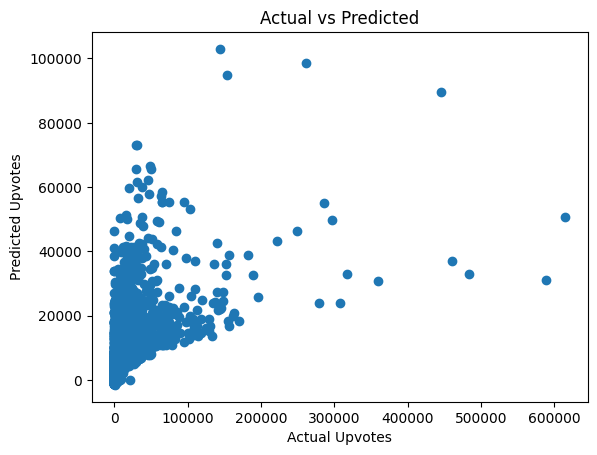

In [65]:
y_train_pred = model.predict(X)

plt.figure()
plt.scatter(y, y_train_pred)
plt.xlabel("Actual Upvotes")
plt.ylabel("Predicted Upvotes")
plt.title("Actual vs Predicted")
plt.show()